<a href="https://colab.research.google.com/github/Andi97-knou/DataAnalysis/blob/knou/1019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import requests

url = 'http://openapi.seoul.go.kr:8088/44756e536374686434386274764968/json/energyUseDataSummaryInfo/1/5/2020'
api_key = '44756e536374686434386274764968'

response = requests.get(url)
print("응답코드 : ", response.status_code)

if response.status_code == 200:
    data = response.json()
    print("응답 데이터 일부:")
    print(data)
else:
    print("오류 발생:", response.text)

응답코드 :  200
응답 데이터 일부:
{'energyUseDataSummaryInfo': {'list_total_count': 84, 'RESULT': {'CODE': 'INFO-000', 'MESSAGE': '정상 처리되었습니다'}, 'row': [{'YEAR': '2020', 'MON': '12', 'MM_TYPE': '개인', 'CNT': '1110223', 'EUS': '265370372', 'EUS1': '250887378', 'EUS2': '252983409', 'ECO2_1': '13434978.5', 'ECO2_2': '5696430.884', 'GUS': '51095720', 'GUS1': '50449214', 'GUS2': '50298542', 'GCO2_1': '721842', 'GCO2_2': '1616926.08', 'WUS': '15036546.3', 'WUS1': '14479510.234', 'WUS2': '14356727.09', 'WCO2_1': '618427.638', 'WCO2_2': '205317.975816', 'HUS': '26512966.052', 'HUS1': '23787438.214', 'HUS2': '24469734.461', 'HCO2_1': '2384379.7145', 'HCO2_2': '4399125.3465152', 'REG_DATE': '2021-03-11 18:31:32.0'}, {'YEAR': '2020', 'MON': '12', 'MM_TYPE': '기업', 'CNT': '18259', 'EUS': '567429666', 'EUS1': '586794781', 'EUS2': '593462122', 'ECO2_1': '-22698785.5', 'ECO2_2': '-9624285.052', 'GUS': '24795758', 'GUS1': '21567744', 'GUS2': '26868220', 'GCO2_1': '577776', 'GCO2_2': '1294218.24', 'WUS': '4056394.2

In [42]:
import requests
import pandas as dp
import time



full_url = "http://openapi.seoul.go.kr:8088/44756e536374686434386274764968/json/energyUseDataSummaryInfo/1/5/"
api_key = "44756e536374686434386274764968"

data_list = []

for year in range(2015, 2016):
    for month in range(1, 13):

        url = f"{full_url}{year}/{month}/"
        response = requests.get(url)
        time.sleep(0.5)

        if response.status_code == 200:
            data = response.json()
            rows = data.get("energyUseDataSummaryInfo", {}).get("row", [])

            #if not rows:
             #   print(f"{year}년 {month}월: 데이터 없음")
              #  continue

            indiv_rows = list(filter(lambda r: r.get("MM_TYPE") == "개인", rows))

            if  indiv_rows:
                print(f"{year}년 {month}월 개인 데이터")
                for r in indiv_rows:
                   data_dict = {

                     '년도' : year,
                     '월' : month,
                     '회원구분' : r.get("MM_TYPE") ,
                     'elec' : r.get("EUS"),
                     'gas' : r.get("GUS"),
                     'water' : r.get("WUS"),
                     'heat' : r.get("HUS")

                   }
                   data_list.append(data_dict)

           # else:
           #     print(f"{year}년 {month}월 개인 데이터 없음")

        else:
            print(f"{year}년 {month}월 API 호출 실패: {response.status_code}")

df = pd.DataFrame(data_list)

print("\n", df.describe())




2015년 10월 개인 데이터
2015년 12월 개인 데이터

            년도          월
count     2.0   2.000000
mean   2015.0  11.000000
std       0.0   1.414214
min    2015.0  10.000000
25%    2015.0  10.500000
50%    2015.0  11.000000
75%    2015.0  11.500000
max    2015.0  12.000000


In [43]:
import requests
import pandas as dp
import time



full_url = "http://openapi.seoul.go.kr:8088/44756e536374686434386274764968/json/energyUseDataSummaryInfo/1/5/"
api_key = "44756e536374686434386274764968"

data_list = []
for year in range(2015, 2025):
    for month in range(1, 13):
        url = f"{full_url}{year}/{month}/"
        response = requests.get(url)
        time.sleep(0.5)

        if response.status_code == 200:
            data = response.json()
            rows = data.get("energyUseDataSummaryInfo", {}).get("row", [])

            indiv_rows = list(filter(lambda r: r.get("MM_TYPE") == "개인", rows))

            for r in indiv_rows:
                data_list.append({
                    '년도': year,
                    '월': month,
                    '회원구분': r.get("MM_TYPE"),
                    '전기사용량': r.get("EUS"),
                    '가스사용량': r.get("GUS"),
                    '수도사용량': r.get("WUS"),
                    '지역난방사용량': r.get("HUS"),
                    '데이터기준일자': r.get("DATA_SD")
                })

# DataFrame 생성
df = pd.DataFrame(data_list)

# 기본 정보 출력
print(f"총 데이터 개수: {len(df)}개\n")
print(df.info())
print("\n", df.describe())

KeyboardInterrupt: 

In [36]:
import requests
import time
import pandas as pd

full_url = "http://openapi.seoul.go.kr:8088/44756e536374686434386274764968/json/energyUseDataSummaryInfo/1/5/"
api_key = "44756e536374686434386274764968"

all_data = []

for year in range(2015, 2025):
    for month in range(1, 13):
        url = f"{full_url}{year}/{month}/"
        response = requests.get(url)
        time.sleep(0.5)

        if response.status_code == 200:
            data = response.json()
            rows = data.get("energyUseDataSummaryInfo", {}).get("row", [])

            if not rows:
                continue


            indiv_rows = list(filter(lambda r: r.get("MM_TYPE") == "개인", rows))
            all_data.extend(indiv_rows)


df = pd.DataFrame(all_data)

cols = ["YEAR", "MON", "MM_TYPE", "EUS", "GUS", "WUS", "HUS"]
existing_cols = [c for c in cols if c in df.columns]
df = df[existing_cols]

for col in ["EUS", "GUS", "WUS", "HUS"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


print(df)



    YEAR MON MM_TYPE        EUS       GUS           WUS           HUS
0   2015  10      개인  186473958   8924018  1.471183e+07  3.167520e+06
1   2015  12      개인  203388142  40095231  1.390416e+07  2.110262e+07
2   2016  10      개인  197827666  10129547  1.517367e+07  2.142328e+06
3   2016  11      개인  204812090  23915383  7.215169e+06  1.086540e+07
4   2017  10      개인  202205893  11910453  1.381136e+07  2.177858e+06
5   2017  11      개인  215620132  26041170  1.326839e+07  1.229067e+07
6   2018  11      개인  227294230  31239511  1.370669e+07  1.027629e+07
7   2018  12      개인  238692561  54019855  1.373249e+07  2.042185e+07
8   2019  10      개인  228095713  11876816  1.480436e+07  2.590192e+06
9   2019  11      개인  231283724  24835894  1.412304e+07  1.498336e+07
10  2019  12      개인  244976724  54509050  1.418479e+07  2.355826e+07
11  2020  11      개인  247308528  30095679  1.483501e+07  1.288274e+07
12  2020  12      개인  265370372  51095720  1.503655e+07  2.651297e+07
13  2021  10      개인

In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache –fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (5,744 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126675 files and dire

In [2]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

/tmp/ipython-input-2786205172.py:90: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  plt.savefig("energy_total_change_1234.png", dpi=300, bbox_inches="tight")
/tmp/ipython-input-2786205172.py:90: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.savefig("energy_total_change_1234.png", dpi=300, bbox_inches="tight")
/tmp/ipython-input-2786205172.py:90: UserWarning: Glyph 45320 (\N{HANGUL SYLLABLE NEO}) missing from font(s) DejaVu Sans.
  plt.savefig("energy_total_change_1234.png", dpi=300, bbox_inches="tight")
/tmp/ipython-input-2786205172.py:90: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.savefig("energy_total_change_1234.png", dpi=300, bbox_inches="tight")
/tmp/ipython-input-2786205172.py:90: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.savefig("energy_total_change_1234.png", dpi=300, bbox_inches="tight")
/tmp/ipython-

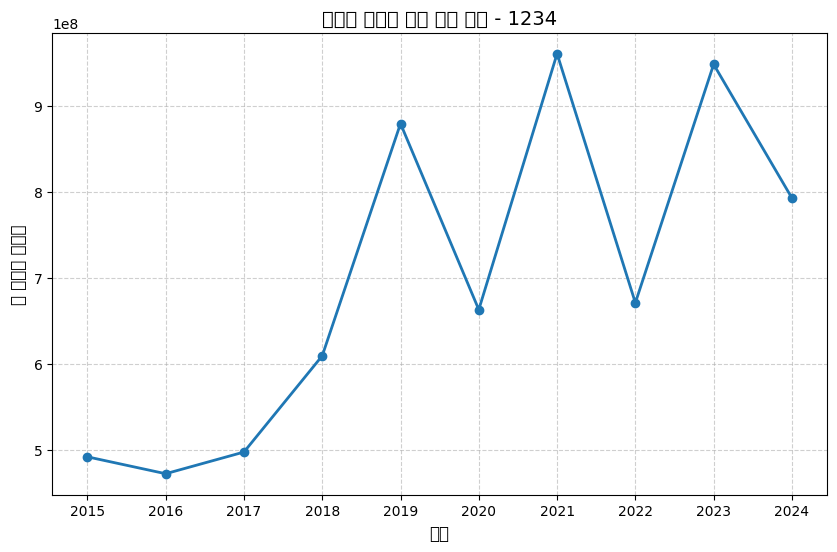

In [3]:
import requests
import time
import pandas as pd

full_url = "http://openapi.seoul.go.kr:8088/44756e536374686434386274764968/json/energyUseDataSummaryInfo/1/5/"
api_key = "44756e536374686434386274764968"

# 전체 데이터를 저장할 리스트
all_data = []

for year in range(2015, 2025):
    for month in range(1, 13):
        url = f"{full_url}{year}/{month}/"
        response = requests.get(url)
        time.sleep(0.3)

        if response.status_code == 200:
            data = response.json()
            rows = data.get("energyUseDataSummaryInfo", {}).get("row", [])

           # if not rows:
           #   print(f"{year}년 {month}월: 데이터 없음")
           #   continue

            # 개인 데이터만 필터링
            indiv_rows = list(filter(lambda r: r.get("MM_TYPE") == "개인", rows))

            if indiv_rows:
           #     print(f"{year}년 {month}월 개인 데이터 수집 완료")
                 all_data.extend(indiv_rows)
           # else:
           #     print(f"{year}년 {month}월 개인 데이터 없음")

        else:
            print(f"{year}년 {month}월 API 호출 실패: {response.status_code}")


df = pd.DataFrame(all_data)

df = df[["YEAR", "MON", "MM_TYPE", "EUS", "GUS", "WUS", "HUS"]]

for col in ["EUS", "GUS", "WUS", "HUS"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

def get_season(month):
    month = int(month)
    if month in [3, 4, 5]:
        return "봄"
    elif month in [6, 7, 8]:
        return "여름"
    elif month in [9, 10, 11]:
        return "가을"
    else:
        return "겨울"

# 계절 컬럼 추가
df["SEASON"] = df["MON"].astype(int).apply(get_season)

# ✅ 컬럼 순서 정리 (MON 포함, DATE 제거)
df = df[["YEAR", "MON", "SEASON", "MM_TYPE", "EUS", "GUS", "WUS", "HUS"]]

# 숫자 지수 표기 없애기
pd.set_option('display.float_format', '{:,.2f}'.format)

#print(df)

# 총 사용량 컬럼 추가
df["TOTAL_USE"] = df["EUS"] + df["GUS"] + df["WUS"] + df["HUS"]

# 연도별 총합 계산
yearly_total = df.groupby("YEAR")["TOTAL_USE"].sum().reset_index()

# 그래프 크기 설정
plt.figure(figsize=(10, 6))

# 선 그래프
plt.plot(yearly_total["YEAR"], yearly_total["TOTAL_USE"], marker="o", linewidth=2)

# 제목 (학번 뒷 4자리 넣기)
plt.title("연도별 에너지 사용 총액 변화 - 1234", fontsize=14)

# 축 이름
plt.xlabel("연도", fontsize=12)
plt.ylabel("총 에너지 사용량", fontsize=12)

# 눈금, 격자 추가
plt.grid(True, linestyle="--", alpha=0.6)

# 그래프 저장
plt.savefig("energy_total_change_1234.png", dpi=300, bbox_inches="tight")

# 화면에 출력
plt.show()

